## 1. Data Loading and Environment Setup

This section initialises the analytical environment and loads the processed ML ready dataset. A dynamic path detection mechanism ensures portability across different computing environments, facilitating reproducible research and collaborative workflows.

In [43]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: c:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


## 2. LSTM Model Development (PyTorch)

This section implements a Long Short-Term Memory (LSTM) neural network for multi-horizon CPI inflation forecasting using PyTorch. The model processes 12-month sequences of economic indicators to predict 1, 3, and 5-month ahead inflation targets simultaneously.

### 2.1 Data Preparation & Sequencing

**Objective**: Prepare data for LSTM by creating temporal sequences with a 12-month lookback window. Apply proper scaling (fitted on training data only) to normalize features and targets.

In [44]:
# Install PyTorch if needed
import subprocess
import sys

try:
    import torch
    print("✓ PyTorch already installed")
except ImportError:
    print("Installing PyTorch...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "-q"])
    print("✓ PyTorch installed successfully")

✓ PyTorch already installed


In [45]:
# Data preparation for LSTM
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Parse date and sort (check if date column exists)
if 'date' not in df.columns:
    print("Available columns:", df.columns.tolist())
    raise ValueError("'date' column not found in dataset")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Define temporal splits (same as before)
train_end = '2017-12-31'
val_end = '2021-12-31'

train_mask = df['date'] <= train_end
val_mask = (df['date'] > train_end) & (df['date'] <= val_end)
test_mask = df['date'] > val_end

print(f"Train: {df[train_mask]['date'].min()} to {df[train_mask]['date'].max()} ({train_mask.sum()} samples)")
print(f"Val:   {df[val_mask]['date'].min()} to {df[val_mask]['date'].max()} ({val_mask.sum()} samples)")
print(f"Test:  {df[test_mask]['date'].min()} to {df[test_mask]['date'].max()} ({test_mask.sum()} samples)")

# Feature and target columns
feature_cols = ['cpi_yoy', 'petrol_yoy', 'bank_rate', 'fx_usd', 'gva_growth', 'unemp_rate',
                'cpi_yoy_l1', 'cpi_yoy_l3', 'cpi_yoy_l6', 'petrol_yoy_l1', 'fx_usd_l1', 
                'bank_rate_l1', 'gva_growth_l1', 'unemp_rate_l1']
target_cols = ['cpi_t1', 'cpi_t3', 'cpi_t5']

# Extract data
X_data = df[feature_cols].values
y_data = df[target_cols].values

# Initialize scalers (fit on training data only)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = X_data[train_mask.values]
X_train_scaled = scaler_X.fit_transform(X_train)

y_train = y_data[train_mask.values]
y_train_scaled = scaler_y.fit_transform(y_train)

# Scale validation and test data
X_val = X_data[val_mask.values]
X_val_scaled = scaler_X.transform(X_val)
y_val = y_data[val_mask.values]
y_val_scaled = scaler_y.transform(y_val)

X_test = X_data[test_mask.values]
X_test_scaled = scaler_X.transform(X_test)
y_test = y_data[test_mask.values]
y_test_scaled = scaler_y.transform(y_test)

print(f"\nScaled data shapes:")
print(f"X_train: {X_train_scaled.shape}, y_train: {y_train_scaled.shape}")
print(f"X_val: {X_val_scaled.shape}, y_val: {y_val_scaled.shape}")
print(f"X_test: {X_test_scaled.shape}, y_test: {y_test_scaled.shape}")

Train: 1997-12-01 00:00:00 to 2017-12-01 00:00:00 (241 samples)
Val:   2018-01-01 00:00:00 to 2021-12-01 00:00:00 (48 samples)
Test:  2022-01-01 00:00:00 to 2025-02-01 00:00:00 (38 samples)

Scaled data shapes:
X_train: (241, 14), y_train: (241, 3)
X_val: (48, 14), y_val: (48, 3)
X_test: (38, 14), y_test: (38, 3)


In [46]:
# Create sequences with 12-month lookback window
lookback = 12

def create_sequences(X, y, lookback):
    """Create sequences for LSTM input"""
    X_seq, y_seq = [], []
    for i in range(len(X) - lookback):
        X_seq.append(X[i:i+lookback])
        y_seq.append(y[i+lookback])
    return np.array(X_seq), np.array(y_seq)

# Create sequences for all splits
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, lookback)
X_val_seq, y_val_seq = create_sequences(X_val_scaled, y_val_scaled, lookback)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, lookback)

print(f"Sequence shapes:")
print(f"X_train_seq: {X_train_seq.shape}, y_train_seq: {y_train_seq.shape}")
print(f"X_val_seq: {X_val_seq.shape}, y_val_seq: {y_val_seq.shape}")
print(f"X_test_seq: {X_test_seq.shape}, y_test_seq: {y_test_seq.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_seq)
y_train_tensor = torch.FloatTensor(y_train_seq)
X_val_tensor = torch.FloatTensor(X_val_seq)
y_val_tensor = torch.FloatTensor(y_val_seq)
X_test_tensor = torch.FloatTensor(X_test_seq)
y_test_tensor = torch.FloatTensor(y_test_seq)

# Create data loaders
batch_size = 16
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nData loaders created with batch_size={batch_size}")

Sequence shapes:
X_train_seq: (229, 12, 14), y_train_seq: (229, 3)
X_val_seq: (36, 12, 14), y_val_seq: (36, 3)
X_test_seq: (26, 12, 14), y_test_seq: (26, 3)

Data loaders created with batch_size=16


### 2.2 LSTM Model Architecture & Training

**Objective**: Define and train PyTorch LSTM model with:
- LSTM layer (64 units) to capture temporal dependencies
- Dropout layers for regularization
- Dense layers for feature transformation
- Multi-output head for simultaneous t1, t3, t5 predictions
- Early stopping to prevent overfitting

In [47]:
# Define LSTM model architecture
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(LSTMForecaster, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout1 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.dropout2 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(32, output_size)
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Use last output
        last_output = lstm_out[:, -1, :]
        x = self.dropout1(last_output)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# Model parameters
input_size = 14  # number of features
hidden_size = 64
num_layers = 1
output_size = 3  # t1, t3, t5
dropout_rate = 0.2

# Initialize model
model = LSTMForecaster(input_size, hidden_size, num_layers, output_size, dropout_rate)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("LSTM Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTM Model Architecture:
LSTMForecaster(
  (lstm): LSTM(14, 64, batch_first=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=3, bias=True)
)

Total parameters: 22,659


In [48]:
# Training loop with early stopping
num_epochs = 100
early_stopping_patience = 10
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []

print("Starting LSTM training...")
print("="*60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    
    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if patience_counter >= early_stopping_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        model.load_state_dict(best_model_state)
        break

print("="*60)
print(f"Training completed. Best validation loss: {best_val_loss:.6f}")

Starting LSTM training...


Epoch 10/100 | Train Loss: 0.029766 | Val Loss: 0.228571

Early stopping at epoch 12
Training completed. Best validation loss: 0.213206


### 2.3 Model Predictions & Inverse Scaling

**Objective**: Generate predictions on training, validation, and test sets. Inverse-scale predictions to original CPI units for interpretability and evaluation.

In [49]:
# Generate predictions on all sets
model.eval()
with torch.no_grad():
    y_train_pred_scaled = model(X_train_tensor).numpy()
    y_val_pred_scaled = model(X_val_tensor).numpy()
    y_test_pred_scaled = model(X_test_tensor).numpy()

# Inverse-scale predictions to original units
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled)

# Also inverse-scale actual values for comparison
y_train_actual = scaler_y.inverse_transform(y_train_seq)
y_val_actual = scaler_y.inverse_transform(y_val_seq)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

print("Predictions generated and inverse-scaled")
print(f"y_train_pred shape: {y_train_pred.shape}")
print(f"y_val_pred shape: {y_val_pred.shape}")
print(f"y_test_pred shape: {y_test_pred.shape}")

Predictions generated and inverse-scaled
y_train_pred shape: (229, 3)
y_val_pred shape: (36, 3)
y_test_pred shape: (26, 3)


### 2.4 Model Evaluation

**Objective**: Calculate performance metrics (MAE, RMSE, R²) for all three forecast horizons across training, validation, and test sets.

In [50]:
# Evaluate model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

horizons = ['t1', 't3', 't5']
results = {}

print("="*80)
print("LSTM MODEL EVALUATION")
print("="*80)

for idx, horizon in enumerate(horizons):
    print(f"\n[{horizon.upper()}] FORECAST")
    print("-" * 80)
    
    # Training metrics
    train_mae = mean_absolute_error(y_train_actual[:, idx], y_train_pred[:, idx])
    train_rmse = np.sqrt(mean_squared_error(y_train_actual[:, idx], y_train_pred[:, idx]))
    train_r2 = r2_score(y_train_actual[:, idx], y_train_pred[:, idx])
    
    # Validation metrics
    val_mae = mean_absolute_error(y_val_actual[:, idx], y_val_pred[:, idx])
    val_rmse = np.sqrt(mean_squared_error(y_val_actual[:, idx], y_val_pred[:, idx]))
    val_r2 = r2_score(y_val_actual[:, idx], y_val_pred[:, idx])
    
    # Test metrics
    test_mae = mean_absolute_error(y_test_actual[:, idx], y_test_pred[:, idx])
    test_rmse = np.sqrt(mean_squared_error(y_test_actual[:, idx], y_test_pred[:, idx]))
    test_r2 = r2_score(y_test_actual[:, idx], y_test_pred[:, idx])
    
    results[horizon] = {
        'train': {'mae': train_mae, 'rmse': train_rmse, 'r2': train_r2},
        'val': {'mae': val_mae, 'rmse': val_rmse, 'r2': val_r2},
        'test': {'mae': test_mae, 'rmse': test_rmse, 'r2': test_r2}
    }
    
    print(f"Train | MAE: {train_mae:.4f} | RMSE: {train_rmse:.4f} | R²: {train_r2:.4f}")
    print(f"Val   | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f} | R²: {val_r2:.4f}")
    print(f"Test  | MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}")

print("\n" + "="*80)

LSTM MODEL EVALUATION

[T1] FORECAST
--------------------------------------------------------------------------------
Train | MAE: 0.5263 | RMSE: 0.6600 | R²: 0.6666
Val   | MAE: 0.7747 | RMSE: 1.0816 | R²: 0.3689
Test  | MAE: 1.3973 | RMSE: 2.0347 | R²: 0.4296

[T3] FORECAST
--------------------------------------------------------------------------------
Train | MAE: 0.5533 | RMSE: 0.7161 | R²: 0.6079
Val   | MAE: 0.9951 | RMSE: 1.5211 | R²: 0.2419
Test  | MAE: 1.0832 | RMSE: 1.3407 | R²: 0.6038

[T5] FORECAST
--------------------------------------------------------------------------------
Train | MAE: 0.6689 | RMSE: 0.8507 | R²: 0.4465
Val   | MAE: 1.5508 | RMSE: 2.2975 | R²: 0.0543
Test  | MAE: 1.0808 | RMSE: 1.3492 | R²: 0.3228



### 2.5 Visualization: Predicted vs Actual

**Objective**: Generate comprehensive visualizations comparing LSTM predictions against actual values for all three forecast horizons across training, validation, and test sets.

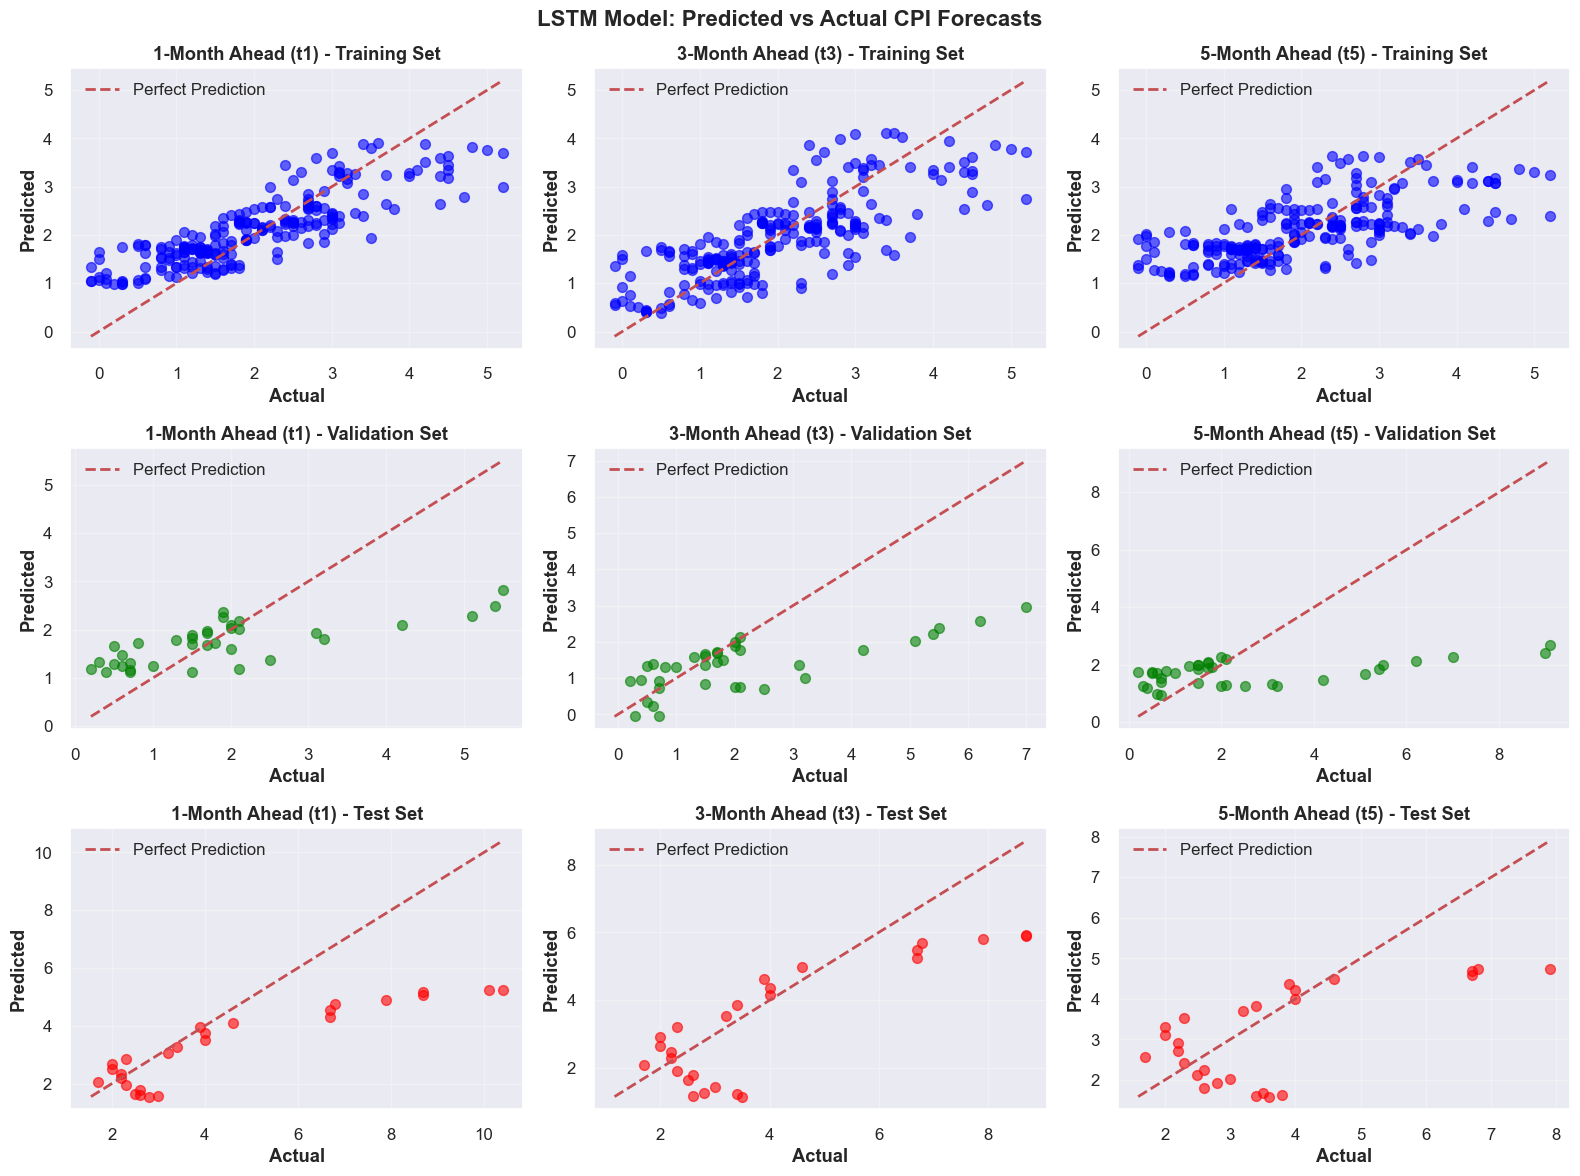

✓ Visualization completed


In [51]:
# Create comprehensive visualizations
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('LSTM Model: Predicted vs Actual CPI Forecasts', fontsize=16, fontweight='bold')

horizons = ['t1', 't3', 't5']
horizon_labels = ['1-Month Ahead (t1)', '3-Month Ahead (t3)', '5-Month Ahead (t5)']

for col, (horizon, label) in enumerate(zip(horizons, horizon_labels)):
    idx = horizons.index(horizon)
    
    # Row 0: Training Set
    ax = axes[0, col]
    ax.scatter(y_train_actual[:, idx], y_train_pred[:, idx], alpha=0.6, s=50, color='blue')
    min_val = min(y_train_actual[:, idx].min(), y_train_pred[:, idx].min())
    max_val = max(y_train_actual[:, idx].max(), y_train_pred[:, idx].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontweight='bold')
    ax.set_ylabel('Predicted', fontweight='bold')
    ax.set_title(f'{label} - Training Set', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Row 1: Validation Set
    ax = axes[1, col]
    ax.scatter(y_val_actual[:, idx], y_val_pred[:, idx], alpha=0.6, s=50, color='green')
    min_val = min(y_val_actual[:, idx].min(), y_val_pred[:, idx].min())
    max_val = max(y_val_actual[:, idx].max(), y_val_pred[:, idx].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontweight='bold')
    ax.set_ylabel('Predicted', fontweight='bold')
    ax.set_title(f'{label} - Validation Set', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()
    
    # Row 2: Test Set
    ax = axes[2, col]
    ax.scatter(y_test_actual[:, idx], y_test_pred[:, idx], alpha=0.6, s=50, color='red')
    min_val = min(y_test_actual[:, idx].min(), y_test_pred[:, idx].min())
    max_val = max(y_test_actual[:, idx].max(), y_test_pred[:, idx].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual', fontweight='bold')
    ax.set_ylabel('Predicted', fontweight='bold')
    ax.set_title(f'{label} - Test Set', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("✓ Visualization completed")

### 2.6 Time Series Visualization: 3-Month Ahead (t3) Forecasts

**Objective**: Display time series line graphs showing actual vs predicted CPI values for the 3-month ahead forecast across all three data splits (training, validation, and test).

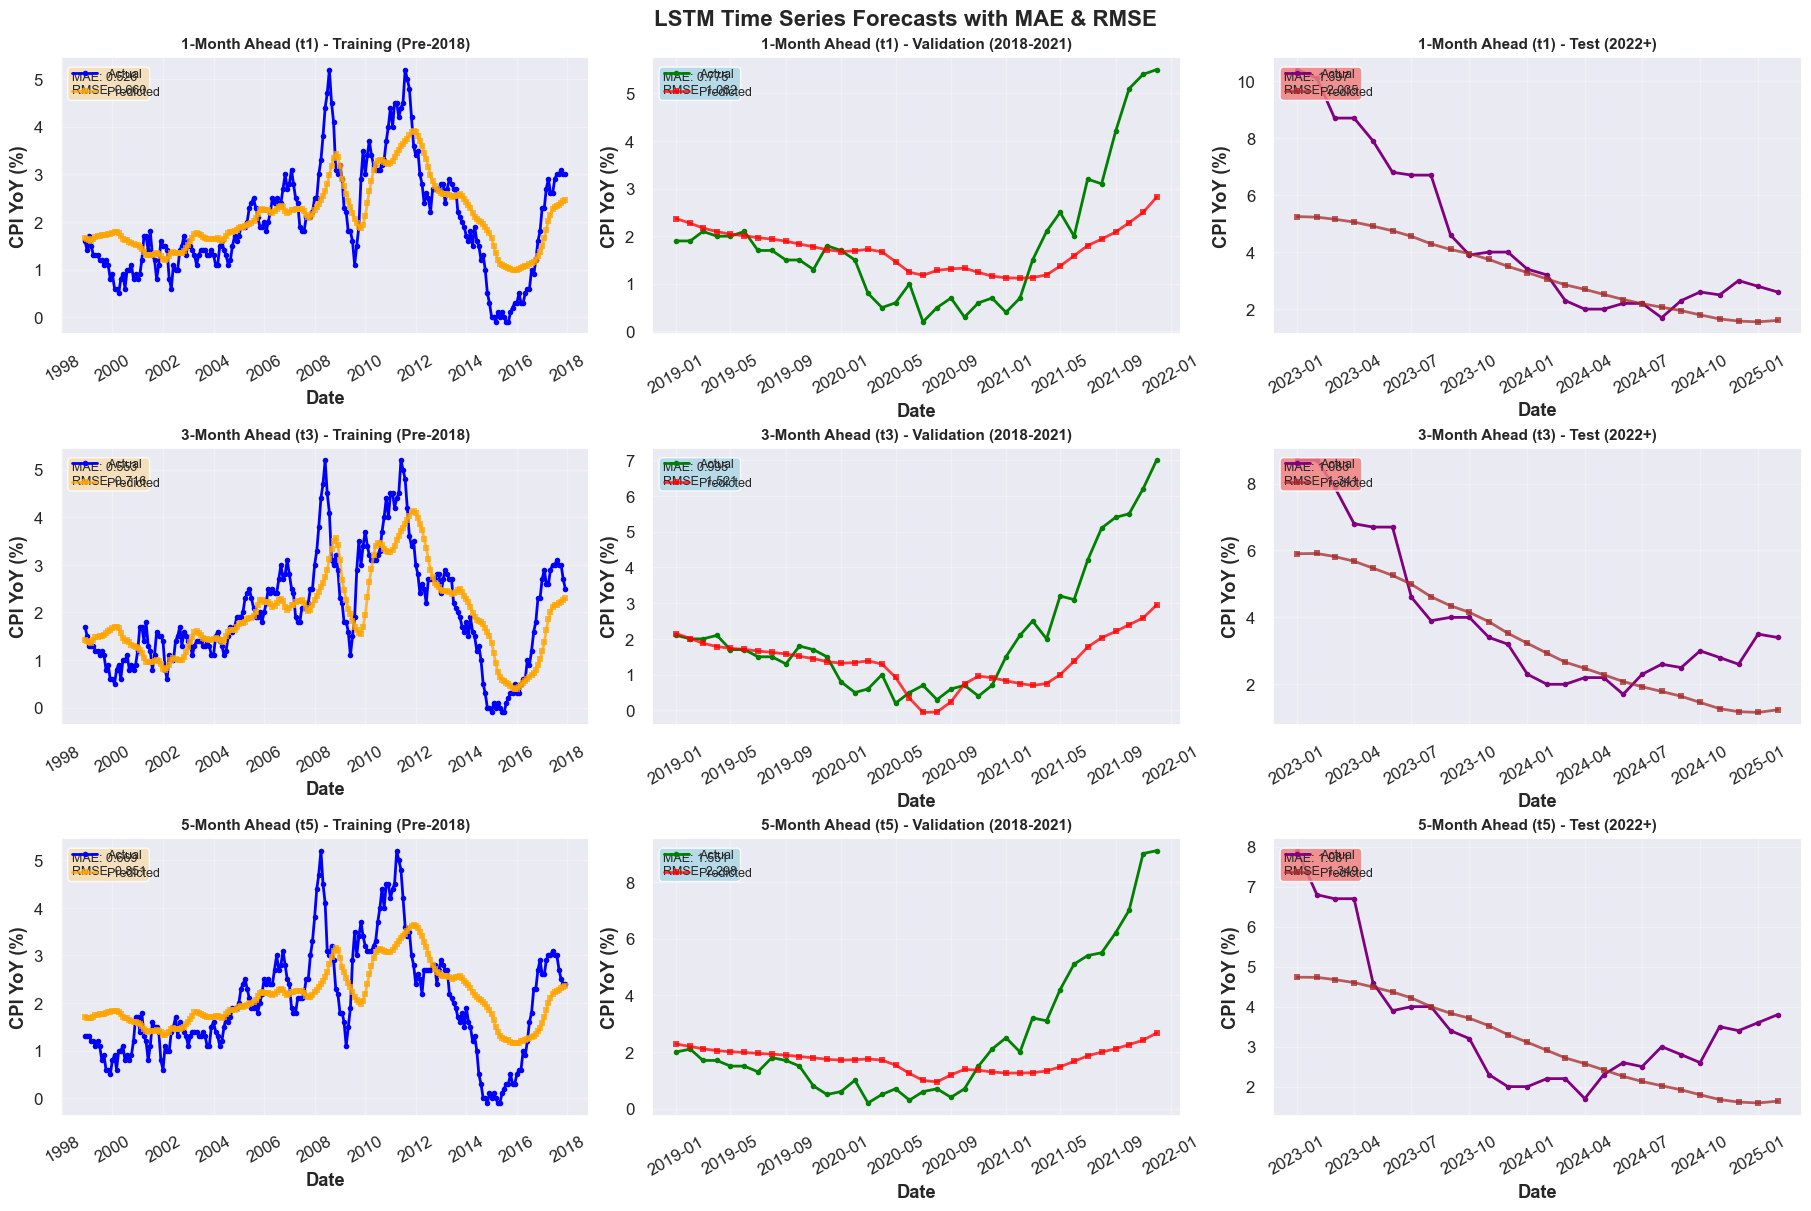

✓ Time series grid regenerated (old style, clearer labels)


In [52]:
# Time series grid (t1, t3, t5) across train/val/test with highlighted metrics
horizons = ['t1', 't3', 't5']
horizon_indices = {'t1': 0, 't3': 1, 't5': 2}
horizon_labels = {'t1': '1-Month Ahead (t1)', 't3': '3-Month Ahead (t3)', 't5': '5-Month Ahead (t5)'}

train_dates = df[train_mask]['date'].values[lookback:]
val_dates = df[val_mask]['date'].values[lookback:]
test_dates = df[test_mask]['date'].values[lookback:]

fig, axes = plt.subplots(3, 3, figsize=(18, 12), constrained_layout=True)
fig.suptitle('LSTM Time Series Forecasts with MAE & RMSE', fontsize=16, fontweight='bold')

split_titles = ['Training (Pre-2018)', 'Validation (2018-2021)', 'Test (2022+)']
split_dates = [train_dates, val_dates, test_dates]
split_actual = [y_train_actual, y_val_actual, y_test_actual]
split_pred = [y_train_pred, y_val_pred, y_test_pred]
split_colors = [('blue', 'orange'), ('green', 'red'), ('purple', 'brown')]
split_boxes = ['wheat', 'lightblue', 'lightcoral']

for row, horizon in enumerate(horizons):
    idx = horizon_indices[horizon]
    label = horizon_labels[horizon]
    for col in range(3):
        ax = axes[row, col]
        dates = split_dates[col]
        actual = split_actual[col][:, idx]
        pred = split_pred[col][:, idx]
        c_actual, c_pred = split_colors[col]
        mae_v = results[horizon][['train', 'val', 'test'][col]]['mae']
        rmse_v = results[horizon][['train', 'val', 'test'][col]]['rmse']

        ax.plot(dates, actual, 'o-', label='Actual', linewidth=2, markersize=4, color=c_actual)
        ax.plot(dates, pred, 's-', label='Predicted', linewidth=2, markersize=4, color=c_pred, alpha=0.75)
        ax.set_title(f'{label} - {split_titles[col]}', fontweight='bold', fontsize=11)
        ax.set_xlabel('Date', fontweight='bold')
        ax.set_ylabel('CPI YoY (%)', fontweight='bold')
        ax.legend(fontsize=9, loc='upper left')
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=30)

        ax.text(0.02, 0.95, f'MAE: {mae_v:.3f}\nRMSE: {rmse_v:.3f}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=split_boxes[col], alpha=0.85))

plt.show()

print("✓ Time series grid regenerated (old style, clearer labels)")

### 2.7 Performance Metrics Comparison: MAE and RMSE

**Objective**: Display MAE and RMSE comparison across all three forecast horizons (t1, t3, t5) for training, validation, and test sets in bar chart format.

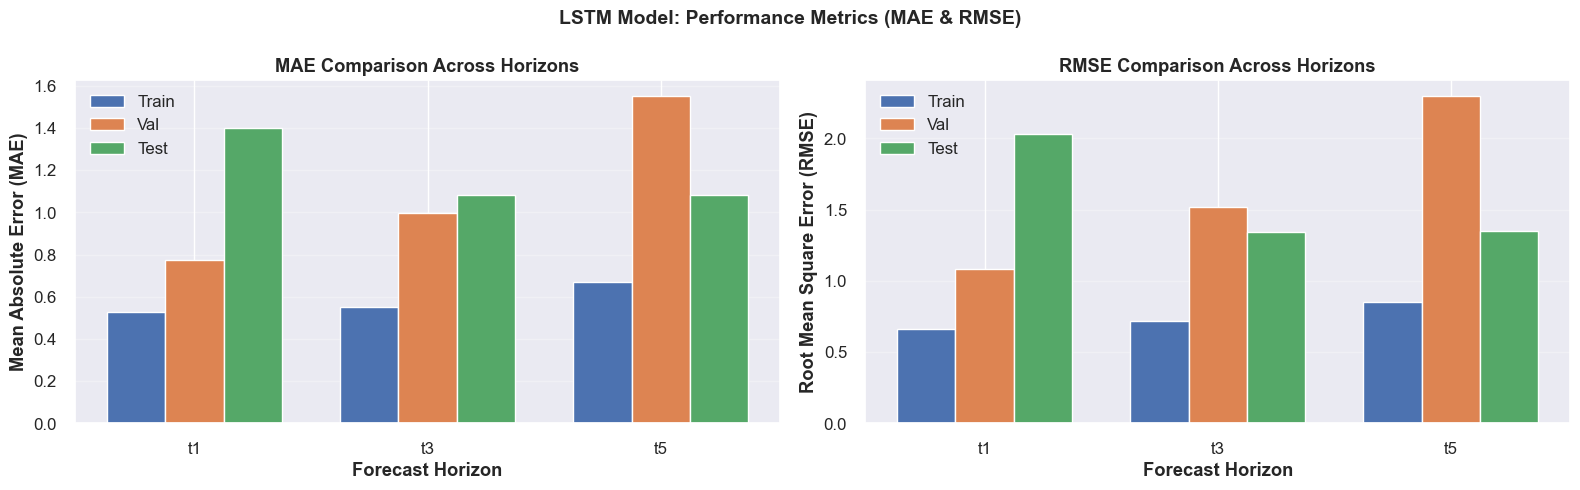


DETAILED PERFORMANCE METRICS TABLE
Horizon   Set      MAE     RMSE
     t1 Train 0.526264 0.659993
     t1   Val 0.774735 1.081581
     t1  Test 1.397342 2.034734
     t3 Train 0.553342 0.716064
     t3   Val 0.995077 1.521072
     t3  Test 1.083240 1.340702
     t5 Train 0.668945 0.850653
     t5   Val 1.550805 2.297507
     t5  Test 1.080771 1.349249
✓ Metrics visualization completed


In [53]:
# Create MAE and RMSE comparison charts
import pandas as pd

# Prepare data for plotting
metrics_data = []
for horizon in ['t1', 't3', 't5']:
    idx = ['t1', 't3', 't5'].index(horizon)
    
    metrics_data.append({
        'Horizon': horizon, 'Set': 'Train', 'MAE': results[horizon]['train']['mae'], 'RMSE': results[horizon]['train']['rmse']
    })
    metrics_data.append({
        'Horizon': horizon, 'Set': 'Val', 'MAE': results[horizon]['val']['mae'], 'RMSE': results[horizon]['val']['rmse']
    })
    metrics_data.append({
        'Horizon': horizon, 'Set': 'Test', 'MAE': results[horizon]['test']['mae'], 'RMSE': results[horizon]['test']['rmse']
    })

metrics_df = pd.DataFrame(metrics_data)

# Create figure with MAE and RMSE subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('LSTM Model: Performance Metrics (MAE & RMSE)', fontsize=14, fontweight='bold')

# MAE Comparison
ax = axes[0]
horizons = ['t1', 't3', 't5']
x = np.arange(len(horizons))
width = 0.25

for i, dataset in enumerate(['Train', 'Val', 'Test']):
    mae_values = [results[h][dataset.lower()]['mae'] for h in horizons]
    ax.bar(x + i*width, mae_values, width, label=dataset)

ax.set_xlabel('Forecast Horizon', fontweight='bold')
ax.set_ylabel('Mean Absolute Error (MAE)', fontweight='bold')
ax.set_title('MAE Comparison Across Horizons', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(horizons)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# RMSE Comparison
ax = axes[1]
for i, dataset in enumerate(['Train', 'Val', 'Test']):
    rmse_values = [results[h][dataset.lower()]['rmse'] for h in horizons]
    ax.bar(x + i*width, rmse_values, width, label=dataset)

ax.set_xlabel('Forecast Horizon', fontweight='bold')
ax.set_ylabel('Root Mean Square Error (RMSE)', fontweight='bold')
ax.set_title('RMSE Comparison Across Horizons', fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(horizons)
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print detailed metrics table
print("\n" + "="*100)
print("DETAILED PERFORMANCE METRICS TABLE")
print("="*100)
print(metrics_df.to_string(index=False))
print("="*100)

print("✓ Metrics visualization completed")

## 3. Random Forest Baseline (tabular, config-aligned)

This section is split into clear code groups to keep things reusable and easy to modify:

1) Load config + data
2) Create temporal splits
3) Prepare features/targets
4) Fit Random Forest models (one per horizon)
5) Predict and evaluate
6) Visualize (optional, separate cell)

In [54]:
# 3.1 Load config + data
import sys, yaml
from pathlib import Path
sys.path.append(str(Path.cwd().parents[0]))  # ensure src import works from notebooks
import pandas as pd
from src.data.preprocessor import temporal_splits
CONFIG_PATH = Path('../configs/hybrid_b.yaml')
config = yaml.safe_load(CONFIG_PATH.read_text())
feature_cols = config['features']['feature_cols']
target_cols = config['features']['target_cols']
df_rf = pd.read_csv('model_ready_dataset.csv')
df_rf['date'] = pd.to_datetime(df_rf['date'])
print('✓ Loaded RF dataset:', df_rf.shape)

✓ Loaded RF dataset: (327, 18)


In [55]:
# 3.4 Fit Random Forest models (one per horizon)
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Centralized RF parameters (defaults + optional YAML overrides)
rf_params = {
    'n_estimators': 400,
    'max_depth': None,
    'min_samples_split': 2,
    'min_samples_leaf': 1,
    'random_state': 42,
    'n_jobs': -1,
}
config_rf = config.get('model', {}).get('rf', {})
for k, v in config_rf.items():
    if k in rf_params:
        rf_params[k] = v

rfs = {}
results_rf = {}
# Fit on train+val to use more data for baseline
# Convert numpy arrays to DataFrames if needed
if isinstance(X_train, np.ndarray):
    X_train_concat = pd.DataFrame(X_train, columns=feature_cols)
    X_val_concat = pd.DataFrame(X_val, columns=feature_cols)
    y_train_concat = pd.DataFrame(y_train, columns=target_cols)
    y_val_concat = pd.DataFrame(y_val, columns=target_cols)
else:
    X_train_concat = X_train
    X_val_concat = X_val
    y_train_concat = y_train
    y_val_concat = y_val

X_fit = pd.concat([X_train_concat, X_val_concat], ignore_index=True)
y_fit = pd.concat([y_train_concat, y_val_concat], ignore_index=True)
for tgt in target_cols:
    rf = RandomForestRegressor(**rf_params)
    rf.fit(X_fit, y_fit[tgt])
    rfs[tgt] = rf
print('✓ Trained RF models per horizon with params:', rf_params)

✓ Trained RF models per horizon with params: {'n_estimators': 400, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42, 'n_jobs': -1}


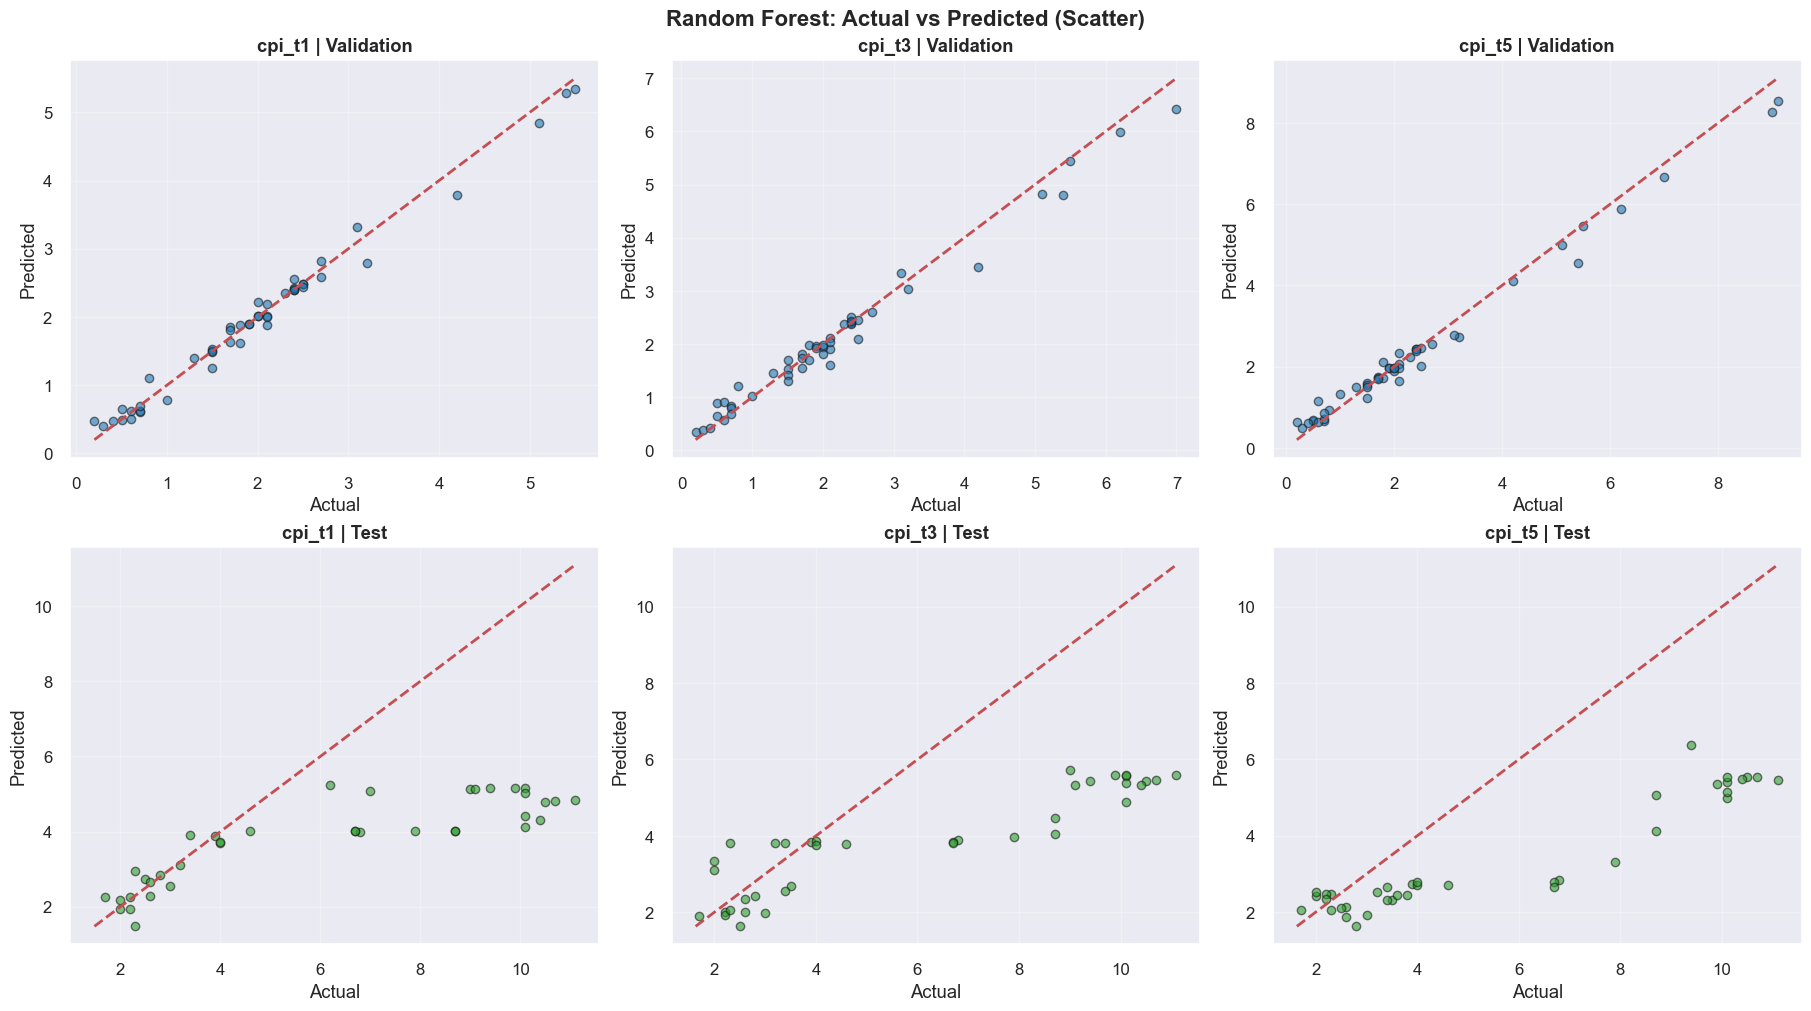

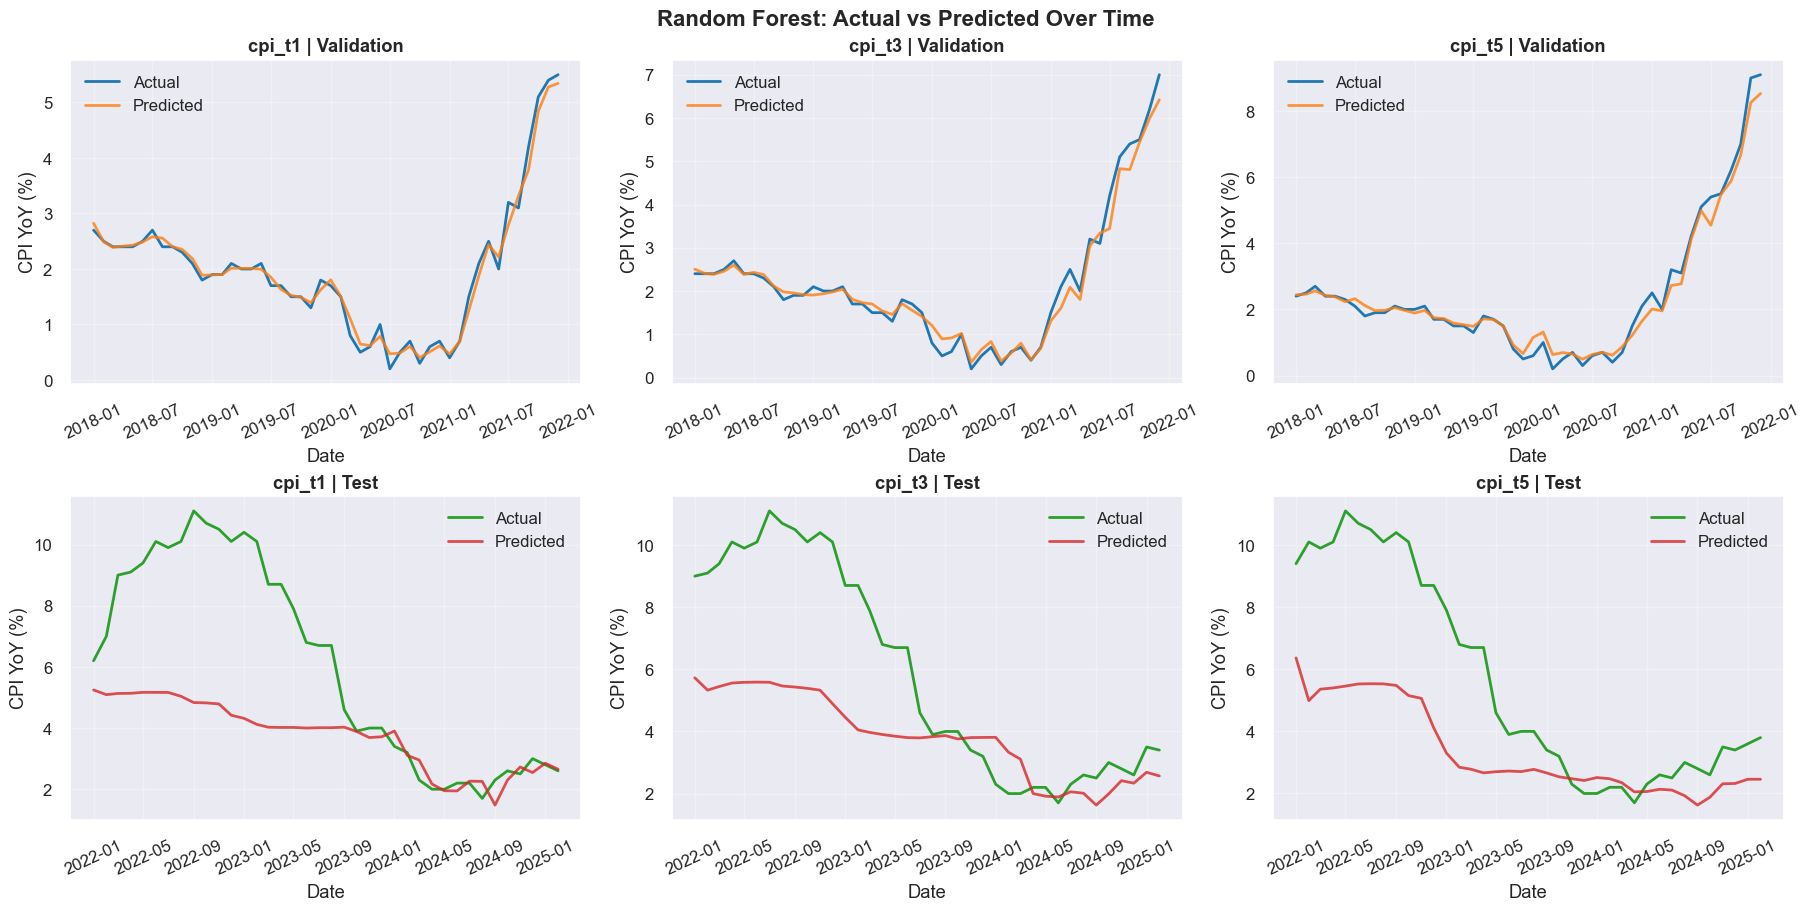

✓ RF scatter and line plots generated


In [58]:
# Visualize RF actual vs predicted (scatter + line) for all horizons
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml, sys
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
sys.path.append(str(Path.cwd().parents[0]))
from src.data.preprocessor import temporal_splits

def _ensure_rf_state():
    """Recreate RF artifacts if this cell runs independently."""
    try:
        _ = rfs, X_val, X_test, y_val, y_test, target_cols, val_mask, test_mask, df_rf, feature_cols
        return rfs, X_val, X_test, y_val, y_test, target_cols, val_mask, test_mask, df_rf, feature_cols
    except NameError:
        CONFIG_PATH = Path('../configs/hybrid_b.yaml')
        config_local = yaml.safe_load(CONFIG_PATH.read_text())
        feature_cols_local = config_local['features']['feature_cols']
        target_cols_local = config_local['features']['target_cols']
        df_rf_local = pd.read_csv('model_ready_dataset.csv')
        df_rf_local['date'] = pd.to_datetime(df_rf_local['date'])
        train_end_local = pd.to_datetime(config_local['data']['train_end'])
        val_end_local = pd.to_datetime(config_local['data']['val_end'])
        train_mask_local, val_mask_local, test_mask_local = temporal_splits(df_rf_local, train_end_local, val_end_local)
        X_local = df_rf_local[feature_cols_local]
        y_local = df_rf_local[target_cols_local]
        X_train_local = X_local[train_mask_local.values]
        X_val_local = X_local[val_mask_local.values]
        X_test_local = X_local[test_mask_local.values]
        y_train_local = y_local[train_mask_local.values]
        y_val_local = y_local[val_mask_local.values]
        y_test_local = y_local[test_mask_local.values]
        rfs_local = {}
        X_fit_local = pd.concat([X_train_local, X_val_local])
        y_fit_local = pd.concat([y_train_local, y_val_local])
        for tgt in target_cols_local:
            rf_model = RandomForestRegressor(
                n_estimators=400,
                max_depth=None,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=42,
                n_jobs=-1,
            )
            rf_model.fit(X_fit_local, y_fit_local[tgt])
            rfs_local[tgt] = rf_model
        return rfs_local, X_val_local, X_test_local, y_val_local, y_test_local, target_cols_local, val_mask_local, test_mask_local, df_rf_local, feature_cols_local

rfs_used, X_val_used, X_test_used, y_val_used, y_test_used, target_cols_used, val_mask_used, test_mask_used, df_rf_used, feature_cols_used = _ensure_rf_state()

# Ensure inputs have correct feature/target names to avoid sklearn warnings
if not isinstance(X_val_used, pd.DataFrame):
    X_val_used = pd.DataFrame(X_val_used, columns=feature_cols_used)
if not isinstance(X_test_used, pd.DataFrame):
    X_test_used = pd.DataFrame(X_test_used, columns=feature_cols_used)
if not isinstance(y_val_used, pd.DataFrame):
    y_val_used = pd.DataFrame(y_val_used, columns=target_cols_used)
if not isinstance(y_test_used, pd.DataFrame):
    y_test_used = pd.DataFrame(y_test_used, columns=target_cols_used)

val_dates = df_rf_used.loc[val_mask_used, 'date']
test_dates = df_rf_used.loc[test_mask_used, 'date']

val_preds = {tgt: rfs_used[tgt].predict(X_val_used) for tgt in target_cols_used}
test_preds = {tgt: rfs_used[tgt].predict(X_test_used) for tgt in target_cols_used}

# Scatter plots
fig, axes = plt.subplots(2, len(target_cols_used), figsize=(18, 10), constrained_layout=True)
split_info = [('Validation', y_val_used, val_preds, 'tab:blue'), ('Test', y_test_used, test_preds, 'tab:green')]
for col, tgt in enumerate(target_cols_used):
    for row, (split_name, y_true_df, y_pred_dict, color) in enumerate(split_info):
        ax = axes[row, col]
        y_true = y_true_df[tgt].values
        y_pred = y_pred_dict[tgt]
        ax.scatter(y_true, y_pred, alpha=0.6, color=color, edgecolor='k')
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
        ax.set_title(f'{tgt} | {split_name}', fontweight='bold')
        ax.set_xlabel('Actual')
        ax.set_ylabel('Predicted')
        ax.grid(alpha=0.3)
plt.suptitle('Random Forest: Actual vs Predicted (Scatter)', fontsize=16, fontweight='bold')
plt.show()

# Line plots over time
fig, axes = plt.subplots(2, len(target_cols_used), figsize=(18, 9), constrained_layout=True)
line_splits = [
    ('Validation', val_dates, y_val_used, val_preds, 'tab:blue', 'tab:orange'),
    ('Test', test_dates, y_test_used, test_preds, 'tab:green', 'tab:red'),
]
for col, tgt in enumerate(target_cols_used):
    for row, (split_name, dates, y_true_df, y_pred_dict, c_true, c_pred) in enumerate(line_splits):
        ax = axes[row, col]
        y_true = y_true_df[tgt].values
        y_pred = y_pred_dict[tgt]
        ax.plot(dates, y_true, label='Actual', color=c_true, linewidth=2)
        ax.plot(dates, y_pred, label='Predicted', color=c_pred, linewidth=2, alpha=0.8)
        ax.set_title(f'{tgt} | {split_name}', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('CPI YoY (%)')
        ax.legend()
        ax.grid(alpha=0.3)
        ax.tick_params(axis='x', rotation=25)
plt.suptitle('Random Forest: Actual vs Predicted Over Time', fontsize=16, fontweight='bold')
plt.show()

print('✓ RF scatter and line plots generated')

### Random Forest Parameters (Editable)
- n_estimators: number of trees (default: 400)
- max_depth: limit tree depth (default: None)
- min_samples_split: min samples to split (default: 2)
- min_samples_leaf: min samples at leaf (default: 1)
- random_state: reproducibility (default: 42)
- n_jobs: CPU cores (default: -1)

You can change them in the RF training cell via the `rf_params` dict or add under `model.rf` in your YAML to override automatically.

In [ ]:
# 3.2 Create temporal splits
from pandas import to_datetime
train_end = to_datetime(config['data']['train_end'])
val_end = to_datetime(config['data']['val_end'])
train_mask, val_mask, test_mask = temporal_splits(df_rf, train_end, val_end)
print('Train/Val/Test sizes:', train_mask.sum(), val_mask.sum(), test_mask.sum())

Train/Val/Test sizes: 241 48 38


In [ ]:
# 3.3 Prepare features/targets
X = df_rf[feature_cols]
y = df_rf[target_cols]
X_train = X[train_mask.values]
X_val = X[val_mask.values]
X_test = X[test_mask.values]
y_train = y[train_mask.values]
y_val = y[val_mask.values]
y_test = y[test_mask.values]
print('Shapes: X_train', X_train.shape, '| X_val', X_val.shape, '| X_test', X_test.shape)

Shapes: X_train (241, 14) | X_val (48, 14) | X_test (38, 14)


In [57]:
# 3.5 Predict and evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Ensure DataFrame inputs with correct feature/target names
X_val_df = X_val if isinstance(X_val, pd.DataFrame) else pd.DataFrame(X_val, columns=feature_cols)
X_test_df = X_test if isinstance(X_test, pd.DataFrame) else pd.DataFrame(X_test, columns=feature_cols)
y_val_df = y_val if isinstance(y_val, pd.DataFrame) else pd.DataFrame(y_val, columns=target_cols)
y_test_df = y_test if isinstance(y_test, pd.DataFrame) else pd.DataFrame(y_test, columns=target_cols)

rows = []
results_rf = {}
for tgt in target_cols:
    y_hat_val = rfs[tgt].predict(X_val_df)
    y_hat_test = rfs[tgt].predict(X_test_df)
    y_true_val = y_val_df[tgt].values
    y_true_test = y_test_df[tgt].values
    results_rf[tgt] = {
        'val': {
            'mae': mean_absolute_error(y_true_val, y_hat_val),
            'rmse': np.sqrt(mean_squared_error(y_true_val, y_hat_val)),
            'r2': r2_score(y_true_val, y_hat_val),
        },
        'test': {
            'mae': mean_absolute_error(y_true_test, y_hat_test),
            'rmse': np.sqrt(mean_squared_error(y_true_test, y_hat_test)),
            'r2': r2_score(y_true_test, y_hat_test),
        },
    }
    rows.append(['val', tgt, results_rf[tgt]['val']['mae'], results_rf[tgt]['val']['rmse'], results_rf[tgt]['val']['r2']])
    rows.append(['test', tgt, results_rf[tgt]['test']['mae'], results_rf[tgt]['test']['rmse'], results_rf[tgt]['test']['r2']])
metrics_rf = pd.DataFrame(rows, columns=['split','horizon','MAE','RMSE','R2'])
print(metrics_rf)

  split horizon       MAE      RMSE        R2
0   val  cpi_t1  0.110656  0.151462  0.984275
1  test  cpi_t1  2.423645  3.327382 -0.022780
2   val  cpi_t3  0.163286  0.236271  0.975851
3  test  cpi_t3  2.329842  3.031322  0.174713
4   val  cpi_t5  0.195214  0.279825  0.981443
5  test  cpi_t5  2.368789  3.045434  0.140264


### Random Forest: Code Group Overview
- Load config + data: reads YAML and `model_ready_dataset.csv`.
- Create temporal splits: uses `temporal_splits()` to make train/val/test by dates.
- Prepare features/targets: builds `X_*` and `y_*` frames from config-selected columns.
- Fit models: trains one `RandomForestRegressor` per horizon using `rf_params`.
- Predict and evaluate: computes MAE, RMSE, and R² for val/test and prints a summary table.
- Visualize: separate cell renders scatter and line plots for all horizons.